### Problem Statement
the project understands how the student's performance is affected byvarious factors such as gender,ethinicity, parental level of education,lunch and test preparation course. The project aims to predict the student's performance based on these factors.

In [1]:
#imports
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
#reading dataset
df = pd.read_csv("data/stud.csv")
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [3]:
df.shape

(1000, 8)

### Datachecks to perform
1. check missing values
2. check duplicate
3. check datatypes
4. check number of unique values
5. check various category present in dataset

In [4]:
#DC1
df.isnull().sum()

#conclusion there is no null values 

gender                         0
race_ethnicity                 0
parental_level_of_education    0
lunch                          0
test_preparation_course        0
math_score                     0
reading_score                  0
writing_score                  0
dtype: int64

In [5]:
#DC2
print(df.duplicated().sum())

#conclusion there is no duplicated values

0


In [6]:
#DC3 check datatype
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race_ethnicity               1000 non-null   object
 2   parental_level_of_education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test_preparation_course      1000 non-null   object
 5   math_score                   1000 non-null   int64 
 6   reading_score                1000 non-null   int64 
 7   writing_score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [7]:
#DC4 check the uniques
df.nunique()

gender                          2
race_ethnicity                  5
parental_level_of_education     6
lunch                           2
test_preparation_course         2
math_score                     81
reading_score                  72
writing_score                  77
dtype: int64

In [8]:
#DC5 Check statistics of dataset
df.describe()

,math_score,reading_score,writing_score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


### feature Engineering
1. creating a output feature total score
2. creating a average score

In [9]:
df['total_score'] = df['math_score'] + df['reading_score'] + df['writing_score']
df['average_score'] = df['total_score']/3
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,total_score,average_score
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


### Visual EDA

<Axes: xlabel='average_score', ylabel='Count'>

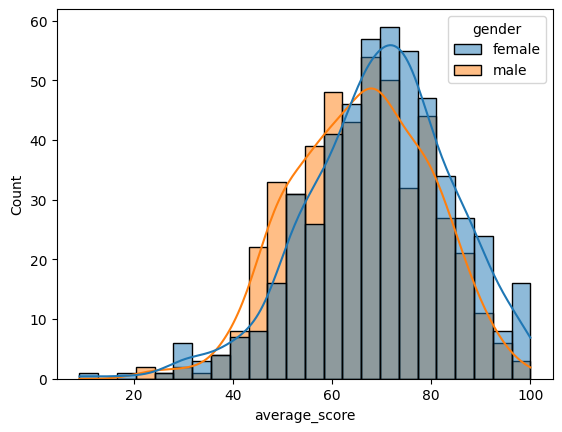

In [10]:
# histogram plotting
sns.histplot(data=df,x='average_score',kde=True,hue='gender')

<Axes: xlabel='math_score', ylabel='Count'>

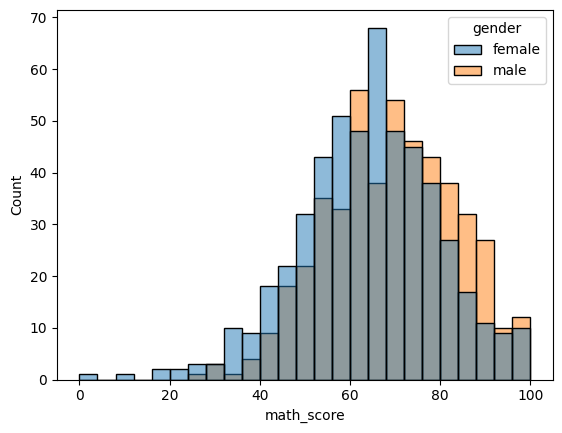

In [11]:
#with ref to female in which subject performance is high
sns.histplot(data=df,x='math_score',hue='gender')

<Axes: xlabel='reading_score', ylabel='Count'>

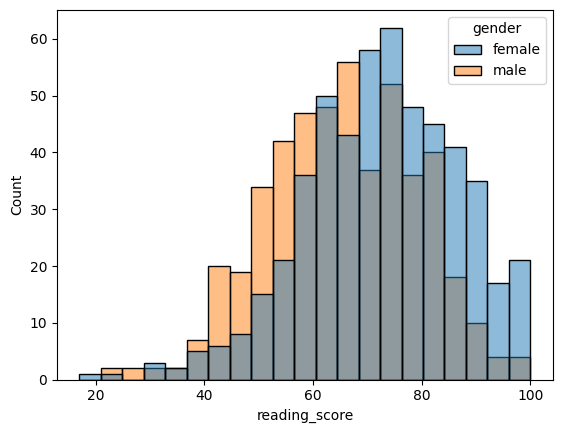

In [12]:
sns.histplot(data=df,x='reading_score',hue='gender')

<Axes: xlabel='writing_score', ylabel='Count'>

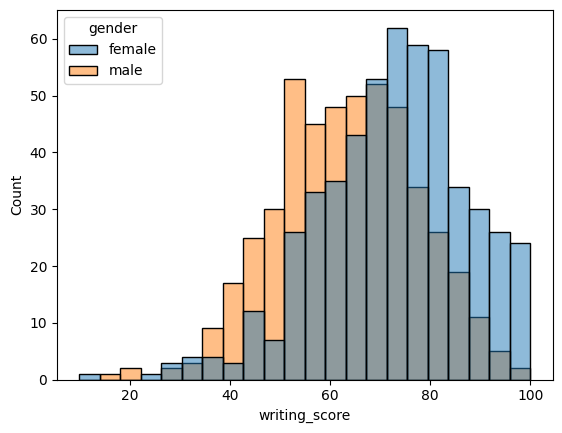

In [13]:
sns.histplot(data=df,x='writing_score',hue='gender')

conclusions female perform well in academics than male

<Axes: ylabel='reading_score'>

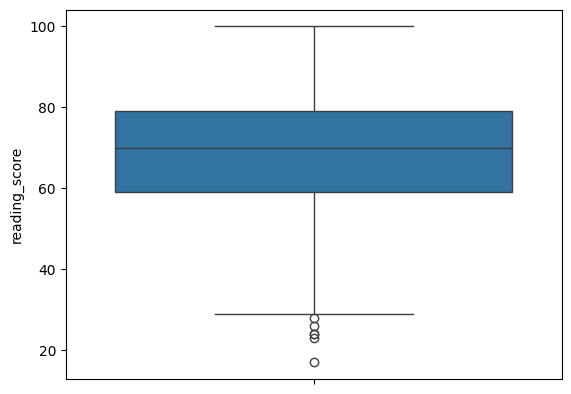

In [ ]:
#checking for outliers
sns.boxplot(df['reading_score'])

<Axes: ylabel='math_score'>

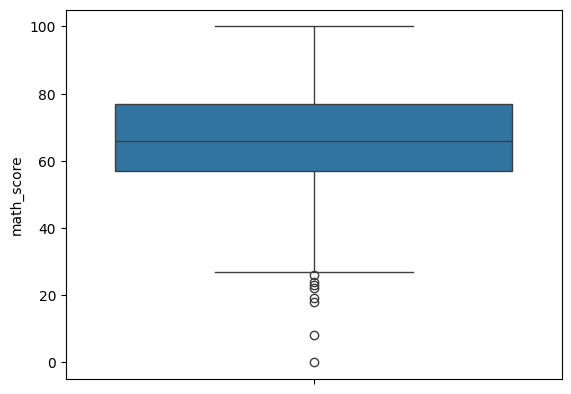

In [15]:
sns.boxplot(df['math_score'])

<Axes: ylabel='writing_score'>

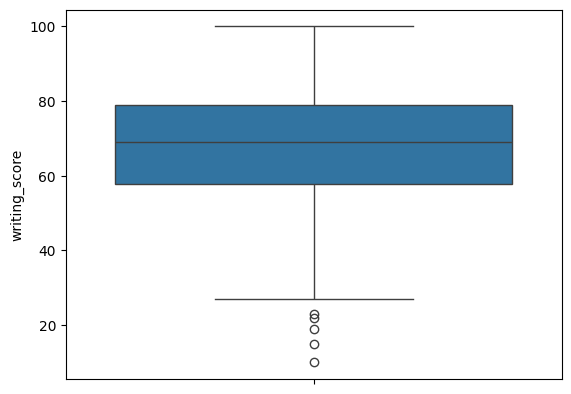

In [17]:
sns.boxplot(df['writing_score'])

In [21]:
#checking for female and male value count
print(df['gender'].value_counts().sum)

<bound method Series.sum of gender
female    518
male      482
Name: count, dtype: int64>
